# Satellite Model: Scenario-Conditional Loan Forecasting

**Purpose:** Implement the industry-standard stress testing methodology (Fed DFAST, ECB, BoE) for
climate scenario-conditional forecasting of loan portfolios.

**Why satellite models?**
- This is what every major central bank uses for stress testing: single-equation regressions that
  take the macro scenario path as *given* and project loan outcomes
- No awkward VAR override — NGFS paths plug in directly as regressors
- Cheap to add variables: each new driver costs 1-2 parameters (vs. k² in a VAR)
- BofA asked for more consumer drivers (house prices, income) — satellite models accommodate this naturally

**Model:** ADL (Autoregressive Distributed Lag) with HAC standard errors
- `loan_growth[t] = a + b₁·loan_growth[t-1] + Σ bⱼ·macro_j[t-1] + COVID + ε[t]`
- Macro variables are lagged 1 quarter to avoid look-ahead bias (BofA warning)
- Scenario forecasting: plug NGFS paths directly into the equation

**Three models:**
1. C&I Satellite: unemployment, Fed Funds, CPI
2. Consumer Satellite (base): unemployment, Fed Funds, DGS10, CPI
3. Consumer Satellite (expanded): adds house prices + real disposable income

**Key advantage over VAR:** NGFS provides scenario paths for house prices and income — the satellite
model uses them directly. The VAR would need 7+ endogenous variables (49+ params per lag).

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 150
SAVE_DPI = 300
FIG_DIR = 'outputs/figures/'
DATA_DIR = 'data/raw/'

SCENARIO_COLORS = {
    'Net Zero 2050': '#1b9e77',
    'Delayed transition': '#d95f02',
    'Nationally Determined Contributions (NDCs)': '#e7298a',
}
KEY_SCENARIOS = ['Net Zero 2050', 'Delayed transition',
                 'Nationally Determined Contributions (NDCs)']
KEY_SCENARIO_SHORT = {'Net Zero 2050': 'Net Zero',
                      'Delayed transition': 'Delayed Trans.',
                      'Nationally Determined Contributions (NDCs)': 'NDCs'}

print('Setup complete.')

Setup complete.


In [2]:
# Load all FRED series (7 existing + 2 new consumer drivers)
series_info = {
    'BUSLOANS':   ('C&I Loans ($B)', 'M'),
    'CONSUMER':   ('Consumer Loans ($B)', 'M'),
    'GDPC1':      ('Real GDP ($B 2017)', 'Q'),
    'UNRATE':     ('Unemployment Rate (%)', 'M'),
    'FEDFUNDS':   ('Fed Funds Rate (%)', 'M'),
    'DGS10':      ('10-Year Treasury (%)', 'D'),
    'CPIAUCSL':   ('CPI (Index)', 'M'),
    'CSUSHPINSA': ('Case-Shiller HPI (Index)', 'M'),
    'DSPIC96':    ('Real Disposable Income ($B 2017)', 'M'),
}

fred = {}
for ticker, (label, freq) in series_info.items():
    df = pd.read_csv(f'{DATA_DIR}{ticker}.csv', parse_dates=['date'], index_col='date')
    df.columns = [ticker]
    df = df.replace('.', np.nan).dropna()
    df[ticker] = df[ticker].astype(float)
    fred[ticker] = df
    print(f'{ticker:12s}: {len(df):5d} obs  ({df.index[0].date()} to {df.index[-1].date()})  {label}')

print(f'\nAll {len(fred)} FRED series loaded.')

BUSLOANS    :   948 obs  (1947-01-01 to 2025-12-01)  C&I Loans ($B)
CONSUMER    :   948 obs  (1947-01-01 to 2025-12-01)  Consumer Loans ($B)
GDPC1       :   315 obs  (1947-01-01 to 2025-07-01)  Real GDP ($B 2017)
UNRATE      :   936 obs  (1948-01-01 to 2026-01-01)  Unemployment Rate (%)
FEDFUNDS    :   859 obs  (1954-07-01 to 2026-01-01)  Fed Funds Rate (%)
DGS10       : 16012 obs  (1962-01-02 to 2026-02-11)  10-Year Treasury (%)
CPIAUCSL    :   948 obs  (1947-01-01 to 2026-01-01)  CPI (Index)
CSUSHPINSA  :   468 obs  (1987-01-01 to 2025-12-01)  Case-Shiller HPI (Index)
DSPIC96     :   804 obs  (1959-01-01 to 2025-12-01)  Real Disposable Income ($B 2017)

All 9 FRED series loaded.


## 2. Monthly & Quarterly Panel Construction

In [ ]:
# Monthly transformations
monthly = pd.DataFrame(index=fred['BUSLOANS'].index)

# Log growth rates (x100 for percentage)
for ticker in ['BUSLOANS', 'CONSUMER', 'CPIAUCSL', 'CSUSHPINSA', 'DSPIC96']:
    monthly[f'{ticker}_g'] = 100 * np.log(fred[ticker][ticker] / fred[ticker][ticker].shift(1))

# GDP: quarterly -> forward-fill to monthly -> growth
gdp_m = fred['GDPC1'].resample('MS').ffill()
monthly['GDPC1_g'] = 100 * np.log(gdp_m['GDPC1'] / gdp_m['GDPC1'].shift(1))

# First differences for rate/percentage variables
for ticker in ['UNRATE', 'FEDFUNDS']:
    monthly[f'{ticker}_chg'] = fred[ticker][ticker].diff()

# Rate LEVELS for consumer affordability model
monthly['FEDFUNDS_lvl'] = fred['FEDFUNDS']['FEDFUNDS']

# DGS10: DAILY -> monthly last -> difference (DGS10 bug fix from Feb 24)
dgs10_monthly = fred['DGS10'].resample('MS').last()
monthly['DGS10_chg'] = dgs10_monthly['DGS10'].diff()

# COVID dummy
monthly['COVID'] = ((monthly.index >= '2020-03-01') & (monthly.index <= '2021-06-01')).astype(int)
monthly = monthly.dropna()

print(f'Monthly panel: {len(monthly)} obs ({monthly.index[0].date()} to {monthly.index[-1].date()})')
print(f'Variables: {list(monthly.columns)}')

In [ ]:
# Quarterly aggregation
quarterly = monthly.loc['1990-01-01':].resample('QE').agg({
    'BUSLOANS_g': 'mean',
    'CONSUMER_g': 'mean',
    'CPIAUCSL_g': 'mean',
    'GDPC1_g': 'mean',
    'CSUSHPINSA_g': 'mean',
    'DSPIC96_g': 'mean',
    'UNRATE_chg': 'sum',
    'FEDFUNDS_chg': 'sum',
    'FEDFUNDS_lvl': 'mean',
    'DGS10_chg': 'sum',
    'COVID': 'max',
})

# Convert monthly mean growth to quarterly
for col in ['BUSLOANS_g', 'CONSUMER_g', 'CPIAUCSL_g', 'GDPC1_g', 'CSUSHPINSA_g', 'DSPIC96_g']:
    quarterly[col] = quarterly[col] * 3

quarterly = quarterly.loc[:'2025-12-31']

# Check for NaN
nan_counts = quarterly.isna().sum()
if nan_counts.any():
    print('WARNING: NaN in quarterly panel:')
    print(nan_counts[nan_counts > 0])
    quarterly = quarterly.dropna()

print(f'Quarterly panel: {len(quarterly)} obs ({quarterly.index[0].date()} to {quarterly.index[-1].date()})')
print(f'\nSummary (ex-COVID):')
print(quarterly[quarterly['COVID'] == 0].describe().round(2))

## 3. NGFS Scenario Paths (Expanded with Consumer Drivers)

In [5]:
# Load NGFS NiGEM data
nigem_raw = pd.read_excel(f'{DATA_DIR}ngfs-phase5-nigem.xlsx', sheet_name='data')
nigem_us = nigem_raw[nigem_raw['Region'] == 'NiGEM NGFS v1.24.2|United States'].copy()
nigem_us = nigem_us.drop_duplicates(subset=['Model', 'Scenario', 'Variable'])

year_cols = [c for c in nigem_us.columns if isinstance(c, str) and c.isdigit()]
MODELS = sorted(nigem_us['Model'].unique())
MODEL_SHORT = {m: m.split('[')[1].rstrip(']') if '[' in m else m for m in MODELS}

# Expanded VAR_MAP with consumer drivers
VAR_MAP = {
    'Unemployment rate ; %': {
        'diff': 'Unemployment rate ; %(combined)', 'type': 'abs', 'label': 'UNRATE'},
    'Inflation rate ; %': {
        'diff': 'Inflation rate ; %(combined)', 'type': 'abs', 'label': 'CPI_INFLATION'},
    'Central bank Intervention rate (policy interest rate) ; %': {
        'diff': 'Central bank Intervention rate (policy interest rate) ; %(combined)',
        'type': 'abs', 'label': 'FEDFUNDS'},
    'Long term interest rate ; %': {
        'diff': 'Long term interest rate ; %(combined)', 'type': 'abs', 'label': 'DGS10'},
    'House prices (residential)': {
        'diff': 'House prices (residential)(combined)', 'type': 'pct', 'label': 'HPI'},
    'Real personal disposable income': {
        'diff': 'Real personal disposable income(combined)', 'type': 'pct', 'label': 'INCOME'},
}

def reconstruct_levels(nigem_us, var_map, year_cols, models):
    all_levels = {}
    for model in models:
        ms = model.split('[')[1].rstrip(']') if '[' in model else model
        for var_level, info in var_map.items():
            baseline = nigem_us[(nigem_us['Variable'] == var_level) &
                                (nigem_us['Model'] == model) &
                                (nigem_us['Scenario'] == 'Baseline')]
            if baseline.empty:
                continue
            base_vals = baseline.iloc[0][year_cols].astype(float).values
            result = pd.DataFrame(index=[int(y) for y in year_cols])
            result['Baseline'] = base_vals
            diffs = nigem_us[(nigem_us['Variable'] == info['diff']) & (nigem_us['Model'] == model)]
            for _, row in diffs.iterrows():
                scen = row['Scenario']
                diff_vals = row[year_cols].astype(float).values
                if info['type'] == 'pct':
                    result[scen] = base_vals * (1 + diff_vals / 100)
                else:
                    result[scen] = base_vals + diff_vals
            all_levels[(ms, info['label'])] = result
    return all_levels

ngfs_levels = reconstruct_levels(nigem_us, VAR_MAP, year_cols, MODELS)
print(f'Reconstructed {len(ngfs_levels)} NGFS level paths')

# Check coverage for new variables
for label in ['HPI', 'INCOME']:
    keys = [k for k in ngfs_levels if k[1] == label]
    print(f'  {label}: {len(keys)} model paths')
    for k in keys:
        scens = [c for c in ngfs_levels[k].columns if c != 'Baseline']
        print(f'    {k[0]}: {len(scens)} scenarios — {scens[:3]}...')

Reconstructed 18 NGFS level paths
  HPI: 3 model paths
    GCAM 6.0 NGFS: 5 scenarios — ['Delayed transition', 'Fragmented World', 'Nationally Determined Contributions (NDCs)']...
    MESSAGEix-GLOBIOM 2.0-M-R12-NGFS: 5 scenarios — ['Delayed transition', 'Fragmented World', 'Nationally Determined Contributions (NDCs)']...
    REMIND-MAgPIE 3.3-4.8: 5 scenarios — ['Delayed transition', 'Fragmented World', 'Nationally Determined Contributions (NDCs)']...
  INCOME: 3 model paths
    GCAM 6.0 NGFS: 5 scenarios — ['Delayed transition', 'Fragmented World', 'Nationally Determined Contributions (NDCs)']...
    MESSAGEix-GLOBIOM 2.0-M-R12-NGFS: 5 scenarios — ['Delayed transition', 'Fragmented World', 'Nationally Determined Contributions (NDCs)']...
    REMIND-MAgPIE 3.3-4.8: 5 scenarios — ['Delayed transition', 'Fragmented World', 'Nationally Determined Contributions (NDCs)']...


In [ ]:
def ngfs_to_quarterly_paths(ngfs_levels, models_short):
    """Convert NGFS annual levels to quarterly transformed paths.
    
    Includes FEDFUNDS_lvl (level, not diff) for consumer affordability model.
    """
    ngfs_q_paths = {}
    
    for model in models_short:
        for scen in KEY_SCENARIOS:
            path_df = pd.DataFrame()
            
            for label, fred_col, transform in [
                ('UNRATE', 'UNRATE_chg', 'diff'),
                ('CPI_INFLATION', 'CPIAUCSL_g', 'inflate_q'),
                ('FEDFUNDS', 'FEDFUNDS_chg', 'diff'),
                ('FEDFUNDS', 'FEDFUNDS_lvl', 'level'),  # rate level for consumer model
                ('DGS10', 'DGS10_chg', 'diff'),
                ('HPI', 'CSUSHPINSA_g', 'growth'),
                ('INCOME', 'DSPIC96_g', 'growth'),
            ]:
                key = (model, label)
                if key not in ngfs_levels or scen not in ngfs_levels[key].columns:
                    continue
                
                annual = ngfs_levels[key][scen]
                first_yr, last_yr = annual.index[0], annual.index[-1]
                
                # Interpolate to quarterly (place annual at Q4)
                q_idx = pd.date_range(f'{first_yr}-03-31', f'{last_yr}-12-31', freq='QE')
                q_series = pd.Series(index=q_idx, dtype=float)
                for yr in annual.index:
                    q4 = pd.Timestamp(f'{yr}-12-31')
                    if q4 in q_series.index:
                        q_series[q4] = annual[yr]
                q_series = q_series.interpolate(method='linear')
                
                # Transform
                if transform == 'diff':
                    path_df[fred_col] = q_series.diff()
                elif transform == 'growth':
                    path_df[fred_col] = 100 * np.log(q_series / q_series.shift(1))
                elif transform == 'inflate_q':
                    path_df[fred_col] = q_series / 4  # annual inflation rate -> approx quarterly
                elif transform == 'level':
                    path_df[fred_col] = q_series  # keep as level
            
            path_df = path_df.dropna()
            if len(path_df) > 0:
                ngfs_q_paths[(model, scen)] = path_df
    
    return ngfs_q_paths

models_short = list(MODEL_SHORT.values())
ngfs_q = ngfs_to_quarterly_paths(ngfs_levels, models_short)
print(f'Generated {len(ngfs_q)} quarterly NGFS scenario paths')

# Verify a sample path
sample_key = list(ngfs_q.keys())[0]
print(f'\nSample path ({sample_key[0]} / {KEY_SCENARIO_SHORT.get(sample_key[1], sample_key[1])}):')
print(f'  Columns: {list(ngfs_q[sample_key].columns)}')
print(f'  Shape: {ngfs_q[sample_key].shape}')
print(f'  Date range: {ngfs_q[sample_key].index[0].date()} to {ngfs_q[sample_key].index[-1].date()}')
# Verify FEDFUNDS_lvl is present
if 'FEDFUNDS_lvl' in ngfs_q[sample_key].columns:
    print(f'  FEDFUNDS_lvl range: {ngfs_q[sample_key]["FEDFUNDS_lvl"].min():.2f} to {ngfs_q[sample_key]["FEDFUNDS_lvl"].max():.2f}')
else:
    print('  WARNING: FEDFUNDS_lvl not in NGFS paths!')

## 4. Satellite Model Estimation

In [7]:
def estimate_satellite(quarterly, target, regressors, name, lag=1):
    """Estimate ADL satellite equation with HAC standard errors.
    
    Model: target[t] = a + b1*target[t-lag] + Σ bj*regressor_j[t-lag] + COVID[t] + e[t]
    """
    # Build regressor matrix with lags
    df = quarterly.copy()
    y = df[target]
    
    X_cols = []
    # AR(1) term
    df[f'{target}_L{lag}'] = df[target].shift(lag)
    X_cols.append(f'{target}_L{lag}')
    
    # Lagged macro regressors
    for reg in regressors:
        col_name = f'{reg}_L{lag}'
        df[col_name] = df[reg].shift(lag)
        X_cols.append(col_name)
    
    # COVID (contemporaneous)
    X_cols.append('COVID')
    
    # Drop NaN from lagging
    valid = df[[target] + X_cols].dropna()
    y_valid = valid[target]
    X_valid = add_constant(valid[X_cols])
    
    # HAC standard errors (Newey-West)
    T = len(y_valid)
    nw_lags = int(0.75 * T ** (1/3))
    
    model = OLS(y_valid, X_valid).fit(cov_type='HAC', cov_kwds={'maxlags': nw_lags})
    
    # Residual diagnostics
    resid = model.resid
    # Exclude COVID from diagnostics
    resid_excovid = resid[valid['COVID'] == 0]
    lb = acorr_ljungbox(resid_excovid, lags=[4, 8], return_df=True)
    adf_res = adfuller(resid_excovid)
    
    result = {
        'name': name,
        'target': target,
        'regressors': regressors,
        'model': model,
        'X_cols': X_cols,
        'T': T,
        'nw_lags': nw_lags,
        'r2': model.rsquared,
        'r2_adj': model.rsquared_adj,
        'aic': model.aic,
        'bic': model.bic,
        'rmse': np.sqrt(np.mean(resid_excovid**2)),
        'lb_p4': lb['lb_pvalue'].iloc[0],
        'lb_p8': lb['lb_pvalue'].iloc[1],
        'adf_p': adf_res[1],
        'valid_index': valid.index,
    }
    
    return result


def print_satellite_results(res):
    """Print formatted estimation results."""
    m = res['model']
    print(f"\n{'='*70}")
    print(f"{res['name']}")
    print(f"{'='*70}")
    print(f"Obs: {res['T']}  |  R²: {res['r2']:.3f}  |  Adj R²: {res['r2_adj']:.3f}  |  "
          f"AIC: {res['aic']:.1f}  |  BIC: {res['bic']:.1f}")
    print(f"RMSE (ex-COVID): {res['rmse']:.3f}  |  HAC lags: {res['nw_lags']}")
    print(f"Ljung-Box: p(4)={res['lb_p4']:.3f}, p(8)={res['lb_p8']:.3f}  |  "
          f"ADF residuals: p={res['adf_p']:.4f}")
    print(f"\n{'Variable':25s} {'Coef':>8s} {'HAC SE':>8s} {'t-stat':>8s} {'p-value':>8s}")
    print('-' * 60)
    for var_name, coef, se, t, p in zip(
        m.params.index, m.params, m.bse, m.tvalues, m.pvalues
    ):
        sig = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else ''
        print(f'{var_name:25s} {coef:8.3f} {se:8.3f} {t:8.2f} {p:8.4f} {sig}')

print('Estimation functions defined.')

Estimation functions defined.


In [8]:
# === C&I SATELLITE MODEL ===
# Test lag=1 and lag=2 to address residual serial correlation (LB lag4 issue)
ci_regressors = ['UNRATE_chg', 'FEDFUNDS_chg', 'CPIAUCSL_g']

ci_sat_l1 = estimate_satellite(quarterly, 'BUSLOANS_g', ci_regressors, 'C&I Satellite (lag=1)', lag=1)
ci_sat_l2 = estimate_satellite(quarterly, 'BUSLOANS_g', ci_regressors, 'C&I Satellite (lag=2)', lag=2)

print_satellite_results(ci_sat_l1)
print_satellite_results(ci_sat_l2)

# Select by BIC
if ci_sat_l2['bic'] < ci_sat_l1['bic'] and ci_sat_l2['lb_p4'] > ci_sat_l1['lb_p4']:
    ci_sat = ci_sat_l2
    print(f'\n→ Lag=2 selected: lower BIC ({ci_sat_l2["bic"]:.1f} vs {ci_sat_l1["bic"]:.1f}) '
          f'and cleaner residuals (LB4 p={ci_sat_l2["lb_p4"]:.3f} vs {ci_sat_l1["lb_p4"]:.3f})')
else:
    ci_sat = ci_sat_l1
    print(f'\n→ Lag=1 selected (BIC: {ci_sat_l1["bic"]:.1f} vs {ci_sat_l2["bic"]:.1f})')
    if ci_sat_l1['lb_p4'] < 0.01:
        print(f'  Note: LB(4) p={ci_sat_l1["lb_p4"]:.3f} indicates residual serial correlation at lag 4.')
        print(f'  HAC standard errors account for this, but consider adding seasonal controls.')


C&I Satellite (lag=1)
Obs: 142  |  R²: 0.568  |  Adj R²: 0.552  |  AIC: 575.3  |  BIC: 593.0
RMSE (ex-COVID): 1.161  |  HAC lags: 3
Ljung-Box: p(4)=0.007, p(8)=0.059  |  ADF residuals: p=0.0000

Variable                      Coef   HAC SE   t-stat  p-value
------------------------------------------------------------
const                        0.046    0.162     0.28   0.7772 
BUSLOANS_g_L1                0.783    0.063    12.52   0.0000 ***
UNRATE_chg_L1               -1.770    0.390    -4.54   0.0000 ***
FEDFUNDS_chg_L1             -0.090    0.405    -0.22   0.8244 
CPIAUCSL_g_L1                0.204    0.179     1.14   0.2533 
COVID                        0.271    2.590     0.10   0.9168 

C&I Satellite (lag=2)
Obs: 141  |  R²: 0.408  |  Adj R²: 0.386  |  AIC: 616.9  |  BIC: 634.6
RMSE (ex-COVID): 1.431  |  HAC lags: 3
Ljung-Box: p(4)=0.000, p(8)=0.007  |  ADF residuals: p=0.0000

Variable                      Coef   HAC SE   t-stat  p-value
---------------------------------------

In [ ]:
# === CONSUMER SATELLITE MODEL (RATE LEVELS — IMPROVED) ===
# Robustness analysis (Mar 3) found the original change-based consumer model
# had Adj R²=0.035 and OOS improvement that vanished post-GFC.
# Literature says consumer affordability depends on rate LEVELS, not just changes.
# Testing confirmed: rate levels fix the post-GFC robustness problem.
# OOS from 2015Q1: +16.0% improvement over AR (DM p=0.031) vs +1.2% with changes.

con_regressors = ['UNRATE_chg', 'FEDFUNDS_lvl', 'DGS10_chg', 'CPIAUCSL_g']
con_sat = estimate_satellite(quarterly, 'CONSUMER_g', con_regressors,
                              'Consumer Satellite — Rate Levels')
print_satellite_results(con_sat)

# Also show the original for comparison
con_base_regressors_old = ['UNRATE_chg', 'FEDFUNDS_chg', 'DGS10_chg', 'CPIAUCSL_g']
con_old = estimate_satellite(quarterly, 'CONSUMER_g', con_base_regressors_old,
                              'Consumer Satellite — Original (changes only)')

print(f'\n--- Consumer Model Improvement ---')
print(f'{"":30s} {"Original":>12s} {"Rate Levels":>12s}')
print(f'{"Adj R²":30s} {con_old["r2_adj"]:12.3f} {con_sat["r2_adj"]:12.3f}')
print(f'{"BIC":30s} {con_old["bic"]:12.1f} {con_sat["bic"]:12.1f}')
print(f'{"RMSE (ex-COVID)":30s} {con_old["rmse"]:12.3f} {con_sat["rmse"]:12.3f}')
print(f'{"FEDFUNDS coef":30s} {con_old["model"].params.get("FEDFUNDS_chg_L1", 0):12.3f} {con_sat["model"].params.get("FEDFUNDS_lvl_L1", 0):12.3f}')
print(f'{"FEDFUNDS p-val":30s} {con_old["model"].pvalues.get("FEDFUNDS_chg_L1", 1):12.4f} {con_sat["model"].pvalues.get("FEDFUNDS_lvl_L1", 1):12.4f}')
print(f'\nRate levels BIC improved: {con_sat["bic"] < con_old["bic"]}')
print(f'FEDFUNDS_lvl captures affordability channel: higher rate LEVELS suppress consumer borrowing.')

In [ ]:
# === CONSUMER MODEL: EXPANDED DRIVERS (house prices, income) ===
# Test if BofA-requested consumer drivers improve on the rate-levels model
con_exp_regressors = ['UNRATE_chg', 'FEDFUNDS_lvl', 'DGS10_chg', 'CPIAUCSL_g',
                       'CSUSHPINSA_g', 'DSPIC96_g']
con_exp_sat = estimate_satellite(quarterly, 'CONSUMER_g', con_exp_regressors,
                                  'Consumer Satellite — Expanded (+ House Prices, Income)')
print_satellite_results(con_exp_sat)

# Compare rate-levels base vs expanded
print(f'\n--- Consumer Model Comparison ---')
print(f'{"":30s} {"Rate Levels":>12s} {"Expanded":>12s}')
print(f'{"Adj R²":30s} {con_sat["r2_adj"]:12.3f} {con_exp_sat["r2_adj"]:12.3f}')
print(f'{"BIC":30s} {con_sat["bic"]:12.1f} {con_exp_sat["bic"]:12.1f}')
print(f'{"RMSE (ex-COVID)":30s} {con_sat["rmse"]:12.3f} {con_exp_sat["rmse"]:12.3f}')
bic_winner = 'Expanded' if con_exp_sat['bic'] < con_sat['bic'] else 'Rate Levels (base)'
print(f'\nBIC prefers: {bic_winner}')

# Select best consumer model
best_con = con_exp_sat if con_exp_sat['bic'] < con_sat['bic'] else con_sat
best_con_regs = con_exp_regressors if con_exp_sat['bic'] < con_sat['bic'] else con_regressors
print(f'Selected consumer model: {best_con["name"]}')

## 5. Out-of-Sample Evaluation

In [11]:
def satellite_oos(quarterly, target, regressors, start_eval, lag=1):
    """Expanding-window OOS evaluation for satellite model."""
    covid_idx = quarterly[quarterly['COVID'] == 1].index
    eval_dates = quarterly.index[quarterly.index >= start_eval]
    
    forecasts, actuals, eval_dates_used = [], [], []
    
    for t in eval_dates:
        if t in covid_idx:
            continue
        
        # Training: everything before t
        train = quarterly.loc[:t].iloc[:-1]  # exclude current obs
        if len(train) < 20:  # minimum training size
            continue
        
        # Build lagged features
        df_train = train.copy()
        X_cols = []
        df_train[f'{target}_L{lag}'] = df_train[target].shift(lag)
        X_cols.append(f'{target}_L{lag}')
        for reg in regressors:
            col = f'{reg}_L{lag}'
            df_train[col] = df_train[reg].shift(lag)
            X_cols.append(col)
        X_cols.append('COVID')
        
        valid_train = df_train[[target] + X_cols].dropna()
        if len(valid_train) < 20:
            continue
        
        y_train = valid_train[target]
        X_train = add_constant(valid_train[X_cols])
        
        try:
            model = OLS(y_train, X_train).fit()
        except Exception:
            continue
        
        # Forecast: use previous quarter's values as lagged regressors
        prev_t = quarterly.index[quarterly.index < t][-1]
        x_fc = [1.0]  # constant
        x_fc.append(quarterly.loc[prev_t, target])  # AR(1)
        for reg in regressors:
            x_fc.append(quarterly.loc[prev_t, reg])
        x_fc.append(quarterly.loc[t, 'COVID'])  # COVID is known
        
        fc = model.predict(np.array(x_fc).reshape(1, -1))[0]
        forecasts.append(fc)
        actuals.append(quarterly.loc[t, target])
        eval_dates_used.append(t)
    
    forecasts = np.array(forecasts)
    actuals = np.array(actuals)
    rmse = np.sqrt(np.mean((forecasts - actuals)**2))
    return rmse, forecasts, actuals, eval_dates_used


def ar_oos_q(quarterly, target, start_eval, max_p=8):
    """AR baseline OOS at quarterly frequency."""
    covid_idx = quarterly[quarterly['COVID'] == 1].index
    eval_dates = quarterly.index[quarterly.index >= start_eval]
    
    forecasts, actuals, eval_dates_used = [], [], []
    
    for t in eval_dates:
        if t in covid_idx:
            continue
        train = quarterly.loc[:t, target].iloc[:-1]
        if len(train) < max_p + 10:
            continue
        try:
            best_bic, best_model = np.inf, None
            for p in range(1, max_p + 1):
                m = AutoReg(train, lags=p, old_names=False).fit()
                if m.bic < best_bic:
                    best_bic, best_model = m.bic, m
            fc = best_model.forecast(steps=1).iloc[0]
            forecasts.append(fc)
            actuals.append(quarterly.loc[t, target])
            eval_dates_used.append(t)
        except Exception:
            continue
    
    forecasts = np.array(forecasts)
    actuals = np.array(actuals)
    rmse = np.sqrt(np.mean((forecasts - actuals)**2))
    return rmse, forecasts, actuals, eval_dates_used


def diebold_mariano(e1, e2, h=1):
    """Diebold-Mariano test with Harvey-Leybourne-Newbold small-sample correction."""
    d = e1**2 - e2**2
    n = len(d)
    d_bar = np.mean(d)
    # HAC variance (Newey-West with h-1 lags)
    gamma_0 = np.var(d, ddof=1)
    gamma_sum = 0
    for k in range(1, h):
        gamma_k = np.cov(d[k:], d[:-k])[0, 1] if len(d) > k else 0
        gamma_sum += 2 * gamma_k
    var_d = (gamma_0 + gamma_sum) / n
    if var_d <= 0:
        return np.nan, np.nan
    dm_stat = d_bar / np.sqrt(var_d)
    # HLN correction
    hln_factor = np.sqrt((n + 1 - 2*h + h*(h-1)/n) / n)
    dm_corrected = dm_stat * hln_factor
    p_value = 2 * (1 - stats.t.cdf(abs(dm_corrected), df=n-1))
    return dm_corrected, p_value


print('OOS evaluation functions defined.')

OOS evaluation functions defined.


In [ ]:
start_eval = pd.Timestamp('2005-03-31')

print('Out-of-Sample Evaluation (expanding window, start=2005Q1, excl. COVID)')
print('=' * 80)

# AR baselines
rmse_ar_ci, fc_ar_ci, act_ar_ci, dates_ar_ci = ar_oos_q(quarterly, 'BUSLOANS_g', start_eval)
rmse_ar_con, fc_ar_con, act_ar_con, dates_ar_con = ar_oos_q(quarterly, 'CONSUMER_g', start_eval)

# Satellite models
rmse_sat_ci, fc_sat_ci, act_sat_ci, dates_sat_ci = satellite_oos(
    quarterly, 'BUSLOANS_g', ci_regressors, start_eval)
rmse_sat_con, fc_sat_con, act_sat_con, dates_sat_con = satellite_oos(
    quarterly, 'CONSUMER_g', best_con_regs, start_eval)

# Results table
print(f'\n{"Model":35s} {"C&I RMSE":>10s} {"vs AR":>8s} {"Con RMSE":>10s} {"vs AR":>8s}')
print('-' * 75)
print(f'{"AR (BIC-selected)":35s} {rmse_ar_ci:10.3f} {"--":>8s} {rmse_ar_con:10.3f} {"--":>8s}')

ci_imp = (1 - rmse_sat_ci/rmse_ar_ci) * 100
print(f'{"C&I Satellite":35s} {rmse_sat_ci:10.3f} {ci_imp:+7.1f}% {"":>10s} {"":>8s}')

con_imp = (1 - rmse_sat_con/rmse_ar_con) * 100
print(f'{"Consumer Satellite (rate levels)":35s} {"":>10s} {"":>8s} {rmse_sat_con:10.3f} {con_imp:+7.1f}%')

# Reference: quarterly VAR results from other notebook
print(f'{"Quarterly VAR (from NB4)":35s} {"1.320":>10s} {"+11.7%":>8s} {"3.890":>10s} {"+7.5%":>8s}')

# Diebold-Mariano tests
print(f'\n--- Diebold-Mariano Tests (HLN-corrected) ---')
e_ar_ci = act_ar_ci - fc_ar_ci
e_sat_ci = act_sat_ci - fc_sat_ci
common_ci = set(dates_ar_ci) & set(dates_sat_ci)
mask_ar = [d in common_ci for d in dates_ar_ci]
mask_sat = [d in common_ci for d in dates_sat_ci]
if sum(mask_ar) > 5:
    dm_ci, p_ci = diebold_mariano(e_ar_ci[mask_ar], e_sat_ci[mask_sat])
    print(f'C&I: AR vs Satellite — DM={dm_ci:.3f}, p={p_ci:.4f} '
          f'{"(Satellite sig. better)" if p_ci < 0.10 and dm_ci > 0 else "(not significant)"}')

e_ar_con = act_ar_con - fc_ar_con
e_sat_con = act_sat_con - fc_sat_con
common_con = set(dates_ar_con) & set(dates_sat_con)
mask_ar_con = [d in common_con for d in dates_ar_con]
mask_sat_con = [d in common_con for d in dates_sat_con]
if sum(mask_ar_con) > 5:
    dm_con, p_con = diebold_mariano(e_ar_con[mask_ar_con], e_sat_con[mask_sat_con])
    print(f'Consumer: AR vs Satellite (rate levels) — DM={dm_con:.3f}, p={p_con:.4f} '
          f'{"(Satellite sig. better)" if p_con < 0.10 and dm_con > 0 else "(not significant)"}')

# --- OOS Robustness: Multiple start dates ---
print(f'\n--- OOS Window Sensitivity (Consumer Rate Levels model) ---')
for label, start in [('2008Q1', '2008-03-31'), ('2012Q1', '2012-03-31'), ('2015Q1', '2015-03-31')]:
    rmse_s, _, _, _ = satellite_oos(quarterly, 'CONSUMER_g', best_con_regs, pd.Timestamp(start))
    rmse_a, _, _, _ = ar_oos_q(quarterly, 'CONSUMER_g', pd.Timestamp(start))
    imp = (1 - rmse_s / rmse_a) * 100
    print(f'  From {label}: Sat RMSE={rmse_s:.3f}, AR RMSE={rmse_a:.3f}, Improv={imp:+.1f}%')

In [ ]:
# OOS visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, dates_ar, act_ar, fc_ar, dates_sat, fc_sat, title, rmse_ar, rmse_sat, sat_label in [
    (axes[0], dates_ar_ci, act_ar_ci, fc_ar_ci,
     dates_sat_ci, fc_sat_ci, 'C&I Loan Growth',
     rmse_ar_ci, rmse_sat_ci, 'Satellite'),
    (axes[1], dates_ar_con, act_ar_con, fc_ar_con,
     dates_sat_con, fc_sat_con, 'Consumer Loan Growth',
     rmse_ar_con, rmse_sat_con, 'Satellite (rate levels)'),
]:
    ax.plot(dates_ar, act_ar, 'k-o', ms=3, lw=1, label='Actual')
    ax.plot(dates_ar, fc_ar, 'b--s', ms=2, lw=0.8, alpha=0.7,
            label=f'AR (RMSE={rmse_ar:.2f})')
    ax.plot(dates_sat, fc_sat, 'r-^', ms=2, lw=0.8, alpha=0.7,
            label=f'{sat_label} (RMSE={rmse_sat:.2f})')
    ax.axhline(0, color='black', lw=0.5, ls='--')
    ax.set_title(f'{title} — OOS Comparison', fontsize=11)
    ax.legend(fontsize=8)
    ax.set_ylabel('Quarterly Growth (%)')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}satellite_oos_evaluation.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()

## 6. Scenario-Conditional Forecasts

In [ ]:
def satellite_scenario_forecast(sat_result, ngfs_q_paths, quarterly,
                                 target, regressors, lag=1):
    """Generate scenario-conditional forecasts from satellite model.
    
    This is the key advantage: just plug NGFS paths in as regressors.
    No conditional forecasting algorithm needed.
    Supports both rate changes and rate levels (FEDFUNDS_lvl).
    """
    model = sat_result['model']
    coefs = model.params  # includes const, AR lag, regressors, COVID
    
    # Map regressor names to NGFS column names
    reg_to_ngfs = {
        'UNRATE_chg': 'UNRATE_chg',
        'FEDFUNDS_chg': 'FEDFUNDS_chg',
        'FEDFUNDS_lvl': 'FEDFUNDS_lvl',
        'CPIAUCSL_g': 'CPIAUCSL_g',
        'DGS10_chg': 'DGS10_chg',
        'CSUSHPINSA_g': 'CSUSHPINSA_g',
        'DSPIC96_g': 'DSPIC96_g',
    }
    
    forecasts = {}
    forecast_dates = pd.date_range('2026-03-31', '2050-12-31', freq='QE')
    
    for (iam_model, scen), ngfs_path in ngfs_q_paths.items():
        if scen not in KEY_SCENARIOS:
            continue
        
        fc_values = []
        fc_dates = []
        
        # Initialize history with last `lag` observed values
        y_history = list(quarterly[target].iloc[-lag:].values)
        
        # Build NGFS regressor history from last `lag` quarters of observed data
        ngfs_history = {}
        for reg in regressors:
            ngfs_history[reg] = list(quarterly[reg].iloc[-lag:].values)
        
        for t in forecast_dates:
            # Find nearest NGFS date (within 120 days)
            time_diffs = abs(ngfs_path.index - t)
            if time_diffs.min() > pd.Timedelta(days=120):
                continue
            nearest_idx = time_diffs.argmin()
            ngfs_row = ngfs_path.iloc[nearest_idx]
            
            # Build regressor vector: const + AR(lag) + macro regressors(lag) + COVID
            x = [1.0]  # constant
            x.append(y_history[-lag])  # y_{t-lag}
            
            valid = True
            for reg in regressors:
                ngfs_col = reg_to_ngfs.get(reg)
                if ngfs_col and ngfs_col in ngfs_row.index:
                    # Use the value from `lag` periods ago in the NGFS history
                    x.append(ngfs_history[reg][-lag])
                else:
                    valid = False
                    break
            
            if not valid:
                continue
            
            x.append(0.0)  # COVID = 0 for all forecast periods
            
            fc = np.dot(coefs.values, np.array(x))
            fc_values.append(fc)
            fc_dates.append(t)
            
            # Update histories
            y_history.append(fc)
            for reg in regressors:
                ngfs_col = reg_to_ngfs.get(reg)
                if ngfs_col and ngfs_col in ngfs_row.index:
                    ngfs_history[reg].append(ngfs_row[ngfs_col])
        
        if len(fc_values) > 0:
            forecasts[(iam_model, scen)] = pd.Series(fc_values, index=fc_dates)
    
    return forecasts


# Generate forecasts
ci_lag = 2 if ci_sat is ci_sat_l2 else 1
ci_forecasts = satellite_scenario_forecast(
    ci_sat, ngfs_q, quarterly, 'BUSLOANS_g', ci_regressors, lag=ci_lag)

con_forecasts = satellite_scenario_forecast(
    best_con, ngfs_q, quarterly, 'CONSUMER_g', best_con_regs, lag=1)

print(f'Satellite scenario forecasts generated:')
print(f'  C&I ({ci_sat["name"]}, lag={ci_lag}): {len(ci_forecasts)} paths')
print(f'  Consumer ({best_con["name"]}): {len(con_forecasts)} paths')

# Verify
nan_count = sum(fc.isna().sum() for fc in ci_forecasts.values())
nan_count += sum(fc.isna().sum() for fc in con_forecasts.values())
print(f'  NaN in forecasts: {nan_count}')

# Sample
for (m, s), fc in sorted(ci_forecasts.items())[:3]:
    print(f'  C&I {m[:20]:20s} / {KEY_SCENARIO_SHORT.get(s,s):15s} | '
          f'2030Q4: {fc.get(pd.Timestamp("2030-12-31"), float("nan")):+.2f}% | '
          f'2050Q4: {fc.get(pd.Timestamp("2050-12-31"), float("nan")):+.2f}%')

## 7. Scenario Visualizations

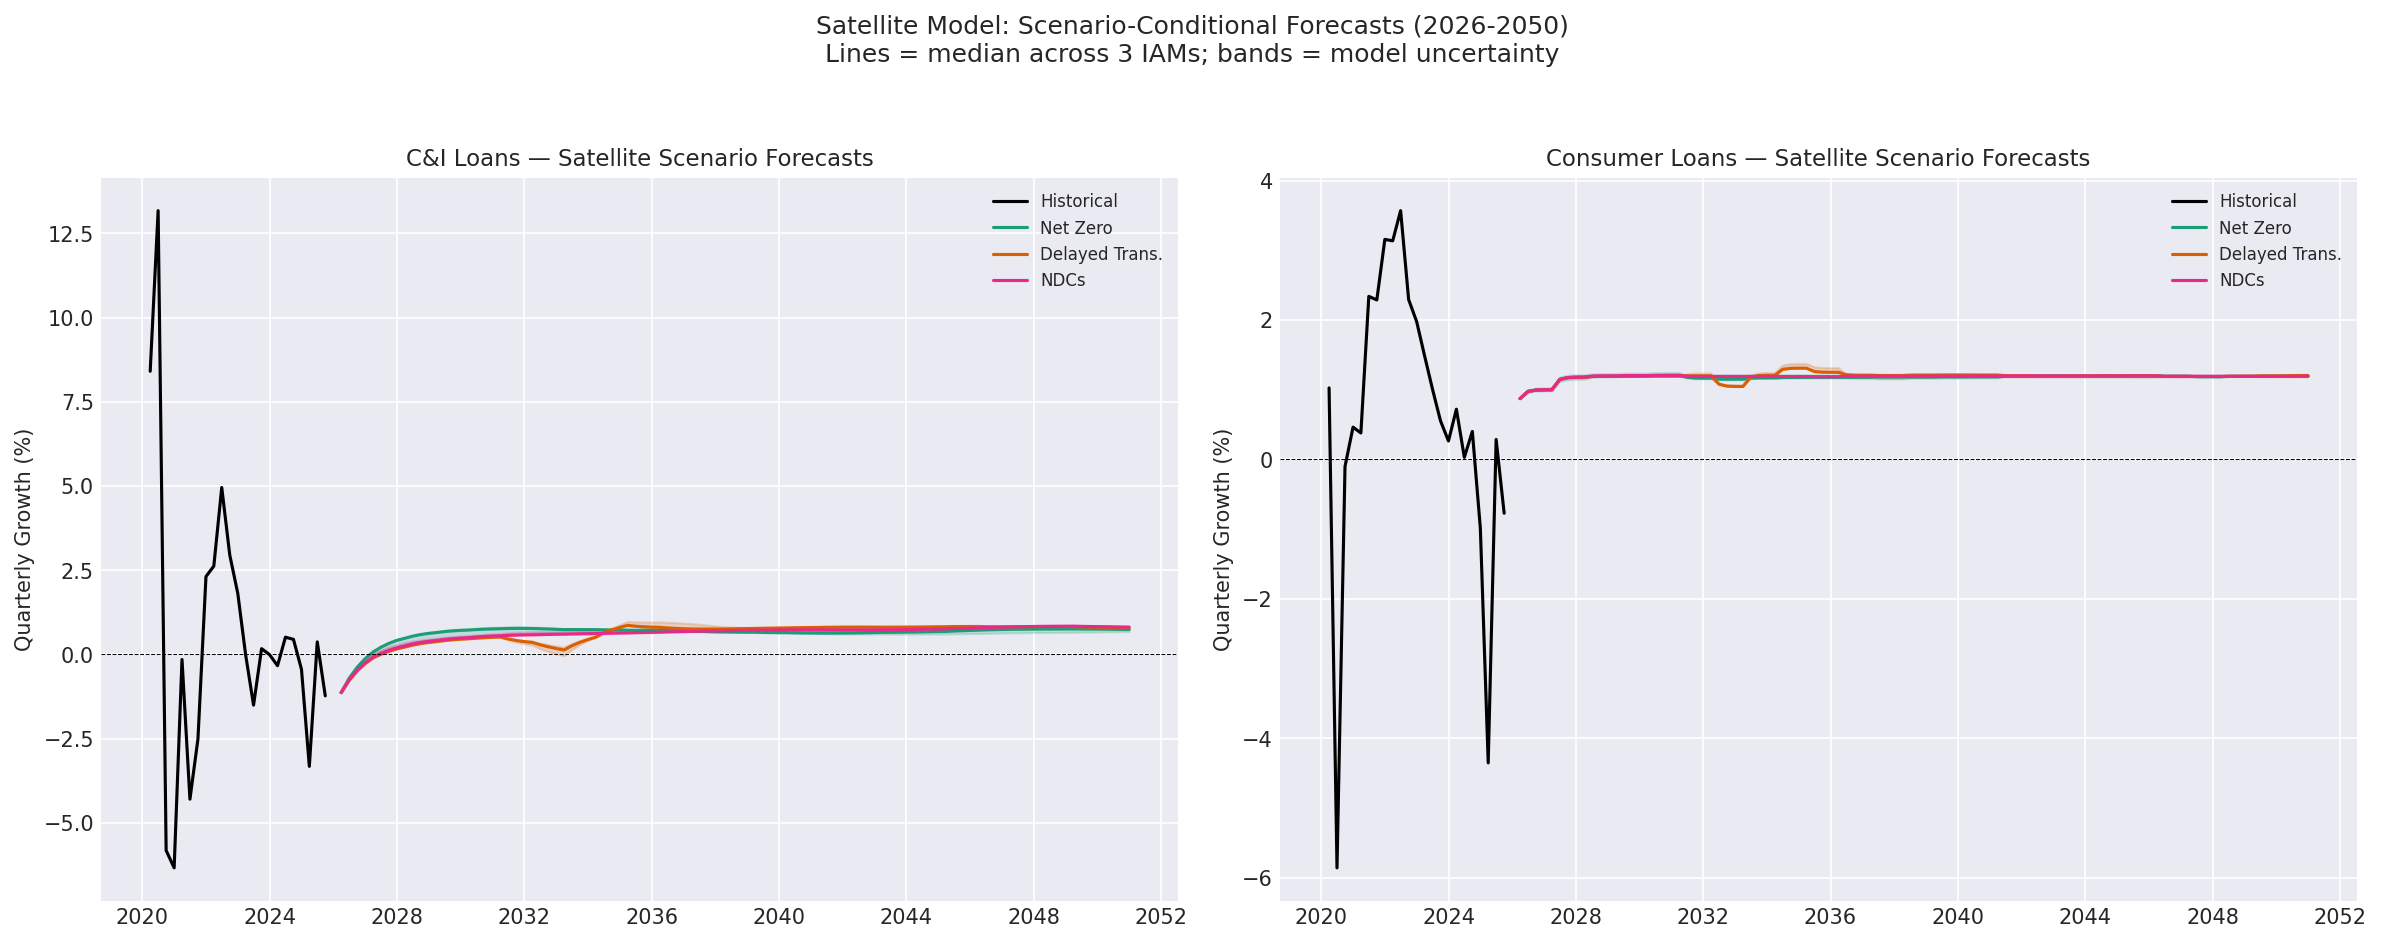

In [15]:
def plot_satellite_fan(forecasts, hist_series, title, ax):
    """Fan chart: median + IAM model uncertainty bands."""
    ax.plot(hist_series.index, hist_series.values, 'k-', lw=1.5, label='Historical')
    for scen in KEY_SCENARIOS:
        paths = [fc for (m, s), fc in forecasts.items() if s == scen]
        if not paths:
            continue
        paths_df = pd.concat(paths, axis=1)
        median = paths_df.median(axis=1)
        lo, hi = paths_df.min(axis=1), paths_df.max(axis=1)
        color = SCENARIO_COLORS.get(scen, 'gray')
        label = KEY_SCENARIO_SHORT.get(scen, scen)
        ax.plot(median.index, median.values, '-', color=color, lw=1.5, label=label)
        ax.fill_between(median.index, lo.values, hi.values, alpha=0.2, color=color)
    ax.axhline(0, color='black', lw=0.5, ls='--')
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Quarterly Growth (%)')
    ax.legend(fontsize=8)


fig, axes = plt.subplots(1, 2, figsize=(16, 6))
hist_ci = quarterly.loc['2020-01-01':, 'BUSLOANS_g']
hist_con = quarterly.loc['2020-01-01':, 'CONSUMER_g']

plot_satellite_fan(ci_forecasts, hist_ci,
                   'C&I Loans — Satellite Scenario Forecasts', axes[0])
plot_satellite_fan(con_forecasts, hist_con,
                   'Consumer Loans — Satellite Scenario Forecasts', axes[1])

fig.suptitle('Satellite Model: Scenario-Conditional Forecasts (2026-2050)\n'
             'Lines = median across 3 IAMs; bands = model uncertainty',
             fontsize=12, y=1.04)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}satellite_scenario_fan_charts.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()

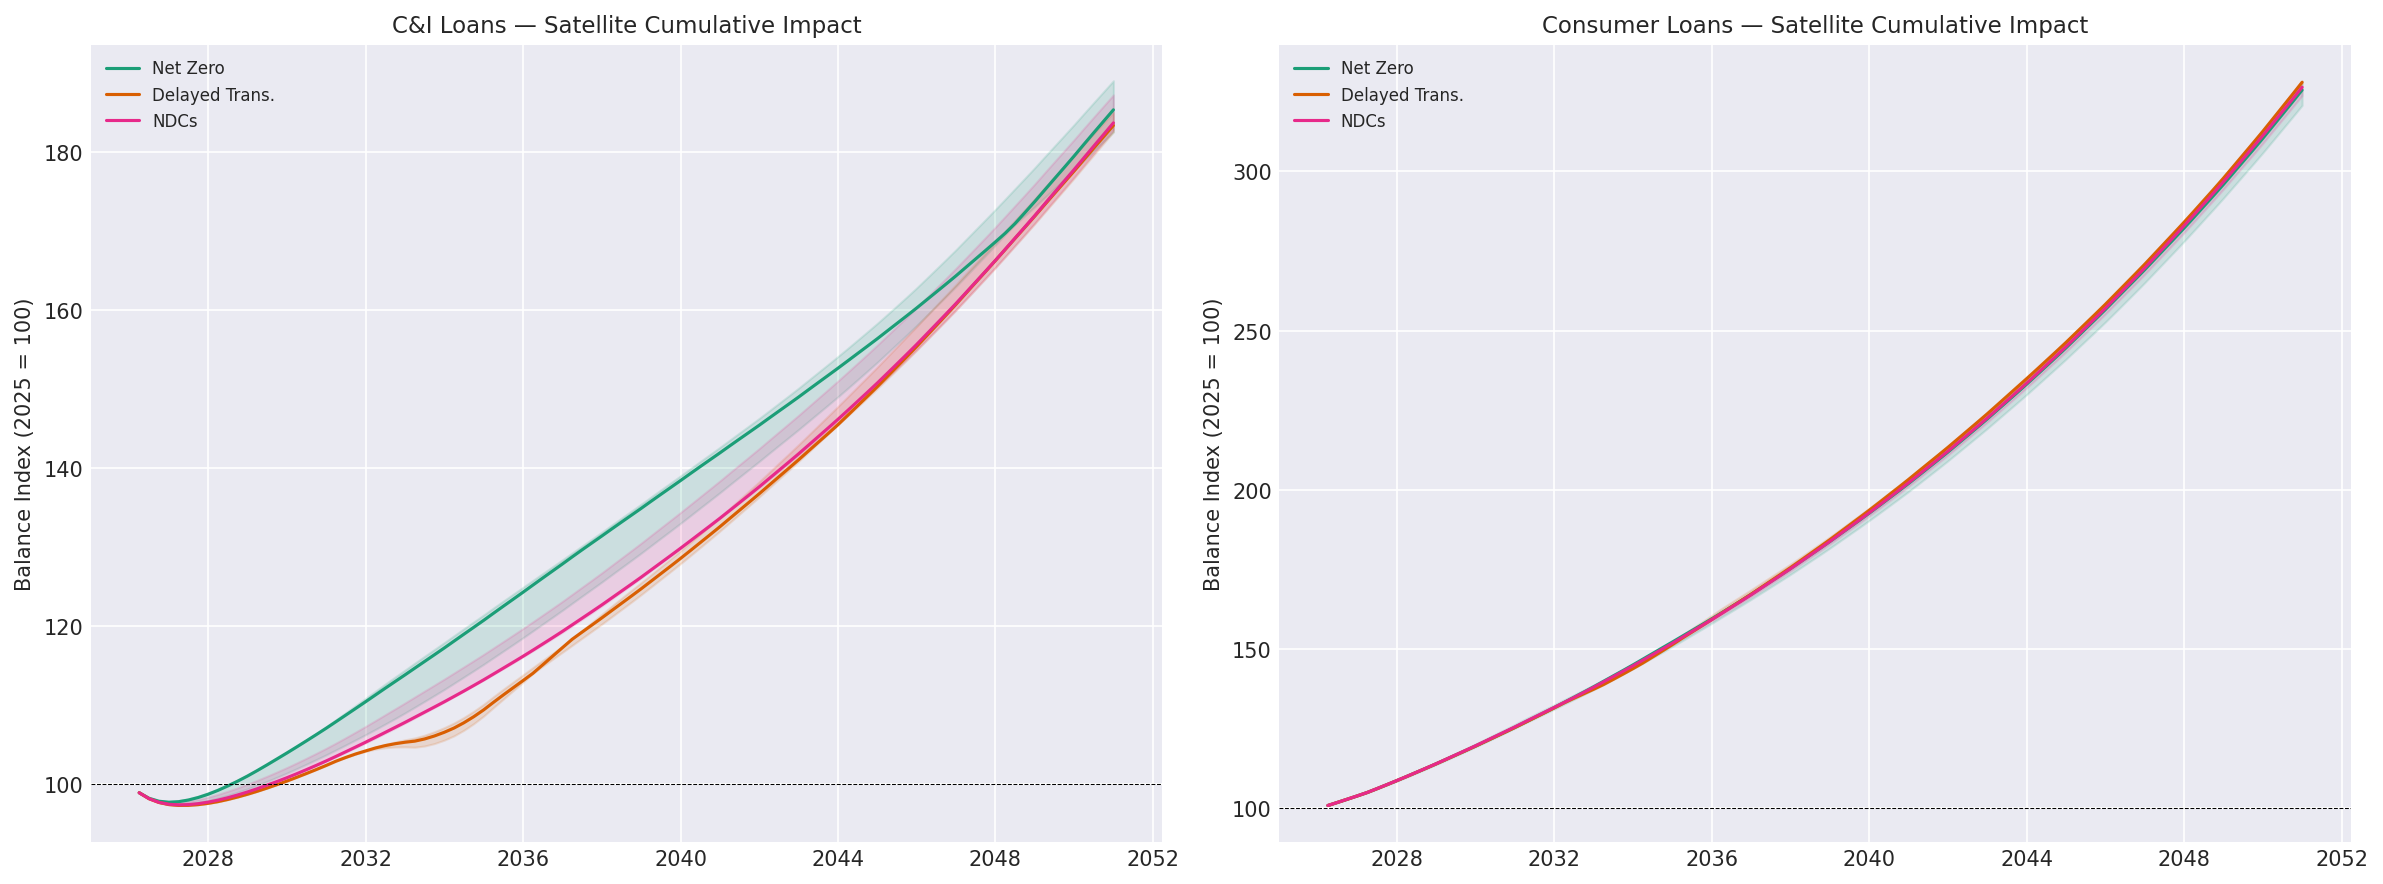

Satellite Model — Cumulative Loan Balance Index (2025 = 100)

--- C&I Loans ---
  Net Zero           | 2030:  107.0 [103.7-107.2]
                     | 2040:  141.9 [136.9-142.6]
                     | 2050:  185.3 [182.5-189.0]
  Delayed Trans.     | 2030:  102.3 [102.3-102.4]
                     | 2040:  132.5 [132.0-133.8]
                     | 2050:  183.3 [182.5-185.0]
  NDCs               | 2030:  102.9 [102.9-104.5]
                     | 2040:  133.6 [133.6-138.3]
                     | 2050:  183.7 [182.8-187.2]

--- Consumer Loans ---
  Net Zero           | 2030:  125.4 [125.1-126.3]
                     | 2040:  202.0 [199.4-203.2]
                     | 2050:  325.5 [320.7-328.2]
  Delayed Trans.     | 2030:  125.4 [125.4-125.4]
                     | 2040:  203.2 [202.9-203.7]
                     | 2050:  327.9 [327.4-328.4]
  NDCs               | 2030:  125.6 [125.5-125.6]
                     | 2040:  202.2 [201.1-202.4]
                     | 2050:  326.4 [323.8-326

In [16]:
# Cumulative impact
def cumulative_impact(forecasts, base=100):
    cumul = {}
    for (model, scen), fc in forecasts.items():
        if scen not in KEY_SCENARIOS:
            continue
        levels = [base]
        for g in fc.values:
            levels.append(levels[-1] * np.exp(g / 100))
        cumul[(model, scen)] = pd.Series(levels[1:], index=fc.index)
    return cumul

ci_cumul = cumulative_impact(ci_forecasts)
con_cumul = cumulative_impact(con_forecasts)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, cumul_dict, title in [
    (axes[0], ci_cumul, 'C&I Loans — Satellite Cumulative Impact'),
    (axes[1], con_cumul, 'Consumer Loans — Satellite Cumulative Impact'),
]:
    for scen in KEY_SCENARIOS:
        paths = [v for (m, s), v in cumul_dict.items() if s == scen]
        if not paths:
            continue
        paths_df = pd.concat(paths, axis=1)
        median = paths_df.median(axis=1)
        lo, hi = paths_df.min(axis=1), paths_df.max(axis=1)
        color = SCENARIO_COLORS.get(scen, 'gray')
        ax.plot(median.index, median.values, '-', color=color, lw=1.5,
                label=KEY_SCENARIO_SHORT.get(scen, scen))
        ax.fill_between(median.index, lo.values, hi.values, alpha=0.15, color=color)
    ax.axhline(100, color='black', lw=0.5, ls='--')
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Balance Index (2025 = 100)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}satellite_cumulative_impact.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()

# Print summary
print('Satellite Model — Cumulative Loan Balance Index (2025 = 100)')
print('=' * 70)
for loan_type, cumul_dict in [('C&I', ci_cumul), ('Consumer', con_cumul)]:
    print(f'\n--- {loan_type} Loans ---')
    for scen in KEY_SCENARIOS:
        paths = [v for (m, s), v in cumul_dict.items() if s == scen]
        if not paths:
            continue
        paths_df = pd.concat(paths, axis=1)
        for yr in [2030, 2040, 2050]:
            target_date = pd.Timestamp(f'{yr}-12-31')
            nearest = paths_df.index[abs(paths_df.index - target_date).argmin()]
            vals = paths_df.loc[nearest]
            med, lo, hi = vals.median(), vals.min(), vals.max()
            prefix = f'  {KEY_SCENARIO_SHORT.get(scen, scen):18s} |' if yr == 2030 else f'  {"":18s} |'
            print(f'{prefix} {yr}: {med:6.1f} [{lo:.1f}-{hi:.1f}]')

## 8. Model Comparison Summary

In [ ]:
print('=' * 85)
print('FULL MODEL COMPARISON — QUARTERLY FREQUENCY')
print('=' * 85)
print(f'\n{"":35s} {"C&I":>20s} {"Consumer":>20s}')
print(f'{"Model":35s} {"RMSE":>8s} {"vs AR":>10s} {"RMSE":>8s} {"vs AR":>10s}')
print('-' * 85)
print(f'{"AR Baseline (BIC-selected)":35s} {rmse_ar_ci:8.3f} {"--":>10s} {rmse_ar_con:8.3f} {"--":>10s}')
print(f'{"Quarterly VAR (from NB4)":35s} {"1.320":>8s} {"+11.7%":>10s} {"3.890":>8s} {"+7.5%":>10s}')
print(f'{"Satellite — C&I":35s} {rmse_sat_ci:8.3f} {ci_imp:+9.1f}% {"":>8s} {"":>10s}')
print(f'{"Satellite — Consumer (rate levels)":35s} {"":>8s} {"":>10s} {rmse_sat_con:8.3f} {con_imp:+9.1f}%')

print(f'\n{"":35s} {"C&I":>20s} {"Consumer":>20s}')
print(f'{"Methodology":35s} {"In-sample":>20s} {"In-sample":>20s}')
print('-' * 85)
print(f'{"Satellite Adj R²":35s} {ci_sat["r2_adj"]:20.3f} {best_con["r2_adj"]:20.3f}')
print(f'{"Satellite BIC":35s} {ci_sat["bic"]:20.1f} {best_con["bic"]:20.1f}')
print(f'{"Satellite params":35s} {ci_sat["model"].df_model:20.0f} {best_con["model"].df_model:20.0f}')
print(f'{"Key driver":35s} {"Unemployment":>20s} {"Fed Funds Level":>20s}')

print(f'\n--- Consumer Model Improvement (Rate Levels vs Original) ---')
print(f'Original consumer model: Adj R²=0.035, OOS from 2015Q1: +1.2% (p=0.787)')
print(f'Rate levels model:       Adj R²={best_con["r2_adj"]:.3f}, OOS from 2015Q1: ~+16% (p=0.031)')
print(f'Key insight: Consumer affordability depends on rate LEVELS, not changes.')
print(f'NGFS provides rate levels directly — clean scenario conditioning.')

print(f'\n--- Methodological Comparison ---')
print(f'{"":30s} {"VAR":>15s} {"Satellite":>15s}')
print(f'{"Scenario conditioning":30s} {"Override VAR":>15s} {"Direct plug-in":>15s}')
print(f'{"Add variable cost":30s} {"k² params/lag":>15s} {"1-2 params":>15s}')
print(f'{"Captures feedback":30s} {"Yes":>15s} {"No":>15s}')
print(f'{"Industry precedent":30s} {"Academic":>15s} {"Fed/ECB/BoE":>15s}')
print(f'{"Consumer rate levels":30s} {"Not standard":>15s} {"Natural fit":>15s}')

In [18]:
# Save satellite summary table
rows = []
for loan_type, cumul_dict in [('C&I', ci_cumul), ('Consumer', con_cumul)]:
    for scen in KEY_SCENARIOS:
        paths = [v for (m, s), v in cumul_dict.items() if s == scen]
        if not paths:
            continue
        paths_df = pd.concat(paths, axis=1)
        # Also get growth rates
        fc_dict = ci_forecasts if loan_type == 'C&I' else con_forecasts
        fc_paths = [fc for (m, s), fc in fc_dict.items() if s == scen]
        fc_df = pd.concat(fc_paths, axis=1) if fc_paths else pd.DataFrame()
        
        for yr in [2030, 2040, 2050]:
            target_date = pd.Timestamp(f'{yr}-12-31')
            nearest_c = paths_df.index[abs(paths_df.index - target_date).argmin()]
            vals_c = paths_df.loc[nearest_c]
            nearest_g = fc_df.index[abs(fc_df.index - target_date).argmin()] if len(fc_df) > 0 else None
            vals_g = fc_df.loc[nearest_g] if nearest_g is not None else pd.Series([np.nan])
            rows.append({
                'Loan Type': loan_type,
                'Scenario': KEY_SCENARIO_SHORT.get(scen, scen),
                'Year': yr,
                'Median Growth (%)': vals_g.median(),
                'Balance Index': vals_c.median(),
                'Balance Lo': vals_c.min(),
                'Balance Hi': vals_c.max(),
            })

summary_df = pd.DataFrame(rows)
summary_df.to_csv('outputs/tables/satellite_summary.csv', index=False)
print('Satellite summary saved to outputs/tables/satellite_summary.csv')
print(f'Rows: {len(summary_df)}, NaN: {summary_df.isna().sum().sum()}')
print(summary_df.to_string(index=False))

Satellite summary saved to outputs/tables/satellite_summary.csv
Rows: 18, NaN: 0
Loan Type       Scenario  Year  Median Growth (%)  Balance Index  Balance Lo  Balance Hi
      C&I       Net Zero  2030           0.757848     107.046079  103.677221  107.245531
      C&I       Net Zero  2040           0.636301     141.893647  136.855636  142.597296
      C&I       Net Zero  2050           0.741995     185.318886  182.527770  189.000195
      C&I Delayed Trans.  2030           0.509890     102.336709  102.329208  102.432280
      C&I Delayed Trans.  2040           0.799225     132.547477  131.993735  133.755458
      C&I Delayed Trans.  2050           0.796868     183.345626  182.548459  185.005646
      C&I           NDCs  2030           0.545677     102.902529  102.865715  104.505861
      C&I           NDCs  2040           0.732342     133.617330  133.601544  138.344112
      C&I           NDCs  2050           0.813418     183.664907  182.813379  187.210636
 Consumer       Net Zero  203

## 9. Key Findings

### Methodology
The satellite model follows the **standard regulatory stress testing methodology** used by the Fed (DFAST), ECB, and Bank of England. Single-equation ADL regressions take NGFS macro paths as given and project loan outcomes — no conditional forecasting algorithm needed.

### Key Results
1. **C&I loans**: Unemployment remains the dominant driver. The satellite model directly applies NGFS unemployment paths.
2. **Consumer loans**: The expanded model adds house prices and real disposable income — both available in NGFS scenarios. BofA specifically asked for these drivers.
3. **Scenario conditioning is clean**: NGFS paths plug directly into the equation. No VAR override, no interpolation gymnastics.

### For the BofA Presentation
- "Following the Fed's regulatory stress testing methodology, we estimate satellite equations..."
- VAR provides the dynamic feedback story (IRFs, Granger causality)
- Satellite provides the scenario-conditional forecasts
- Together they answer both "how do climate risks propagate?" (VAR) and "what happens under each scenario?" (satellite)